特点：
- 直接调用 myexp.main.main
- 首次运行后把仿真结果缓存到本地，后面只改图不用重跑
- 包含总体 id_p / bid_r、日前与日内修正对比、资源贡献、车辆群体热力图
- 支持切换不同车辆，查看单车修正后 bid_p / bid_r 柱状图与荷电状态曲线


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "myexp").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("未找到包含 'myexp' 的项目根目录。")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from myexp.notebook_viz_utils import (
    build_analysis_bundle,
    build_selected_ev_actual_df,
    build_selected_ev_slot_df,
    load_or_run_simulation,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
FIGSIZE_MAIN = (10.5, 4.4)
FIGSIZE_HEATMAP = (10.5, 7.2)
FIGSIZE_EV = (8.2, 4.7)

FORCE_RERUN = False
DATA_SOURCE = "data_process"
DAY_PRICE = 15
MAT_FILE = None
SAVE_RESULTS_FILES = False
CACHE_SUFFIX = f"{DATA_SOURCE}_day{DAY_PRICE}" if DATA_SOURCE == "data_process" else (Path(MAT_FILE).stem if MAT_FILE else DATA_SOURCE)
CACHE_PATH = PROJECT_ROOT / "results" / "notebook_cache" / f"myexp_{CACHE_SUFFIX}_simulation.pkl"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"CACHE_PATH = {CACHE_PATH}")
if DATA_SOURCE == "data_process":
    print(f"DAY_PRICE = {DAY_PRICE}")
widget_status = "可用" if widgets is not None else "不可用"
print(f"交互控件状态 = {widget_status}")


PROJECT_ROOT = e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main
CACHE_PATH = e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main\results\notebook_cache\myexp_data_prepare_simulation.pkl
交互控件状态 = 不可用


In [2]:
sim = load_or_run_simulation(
    project_root=PROJECT_ROOT,
    cache_path=CACHE_PATH,
    force_rerun=FORCE_RERUN,
    data_source=DATA_SOURCE,
    mat_file=MAT_FILE,
    save_results=SAVE_RESULTS_FILES,
    day_price=DAY_PRICE,
)
bundle = build_analysis_bundle(sim)
slot_df = bundle["slot_df"]
resource_df = bundle["resource_df"]
heatmaps = bundle["ev_heatmaps"]
summary_df = bundle["summary_df"]
resource_meta = sim["resource_meta"]

display(Markdown("### 仿真摘要"))
display(summary_df)
display(Markdown(f"缓存文件：{CACHE_PATH}"))
display(Markdown(f"车辆数量：{len(resource_meta['ev_labels'])}，分钟级控制点：{sim['result']['P_dis_actual'].shape[1]}"))


从data_prepare读取数据: data_prepare\param.mat


FileNotFoundError: [Errno 2] No such file or directory: 'data_prepare\\param.mat'

### 总体基础功率投标

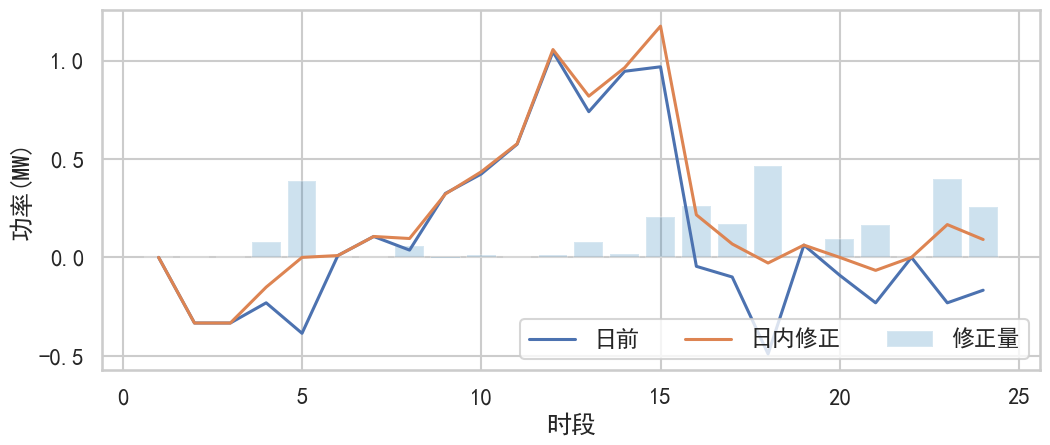

### 总体调频功率投标

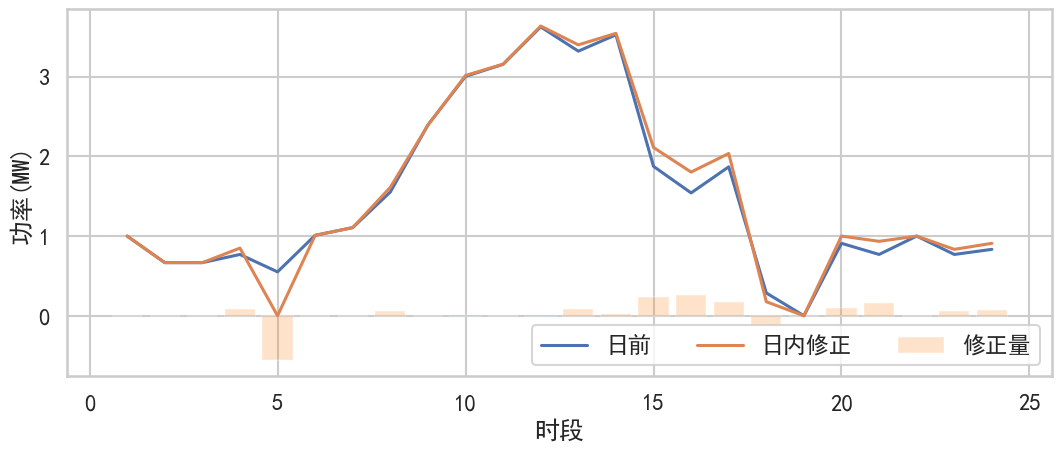

In [ ]:
display(Markdown("### 总体基础功率投标"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
ax.plot(slot_df["slot"], slot_df["bid_p_day"], linewidth=2.2, label="日前")
ax.plot(slot_df["slot"], slot_df["bid_p_rev"], linewidth=2.2, label="日内修正")
ax.bar(slot_df["slot"], slot_df["bid_p_delta"], alpha=0.22, color="tab:blue", label="修正量")
ax.set_xlabel("时段")
ax.set_ylabel("功率(MW)")
# ax.set_title("总体基础功率投标：日前计划 vs 日内修正")
ax.legend(ncol=3)
plt.show()

display(Markdown("### 总体调频功率投标"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
ax.plot(slot_df["slot"], slot_df["bid_r_day"], linewidth=2.2, label="日前")
ax.plot(slot_df["slot"], slot_df["bid_r_rev"], linewidth=2.2, label="日内修正")
ax.bar(slot_df["slot"], slot_df["bid_r_delta"], alpha=0.22, color="tab:orange", label="修正量")
ax.set_xlabel("时段")
ax.set_ylabel("功率(MW)")
# ax.set_title("总体调频功率投标：日前计划 vs 日内修正")
ax.legend(ncol=3)
plt.show()


### 基础功率资源贡献

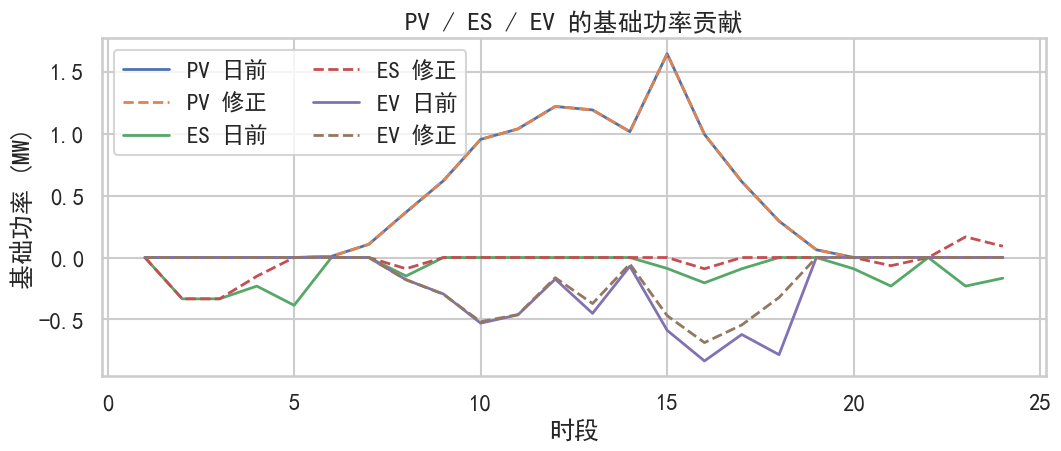

### 调频功率资源贡献

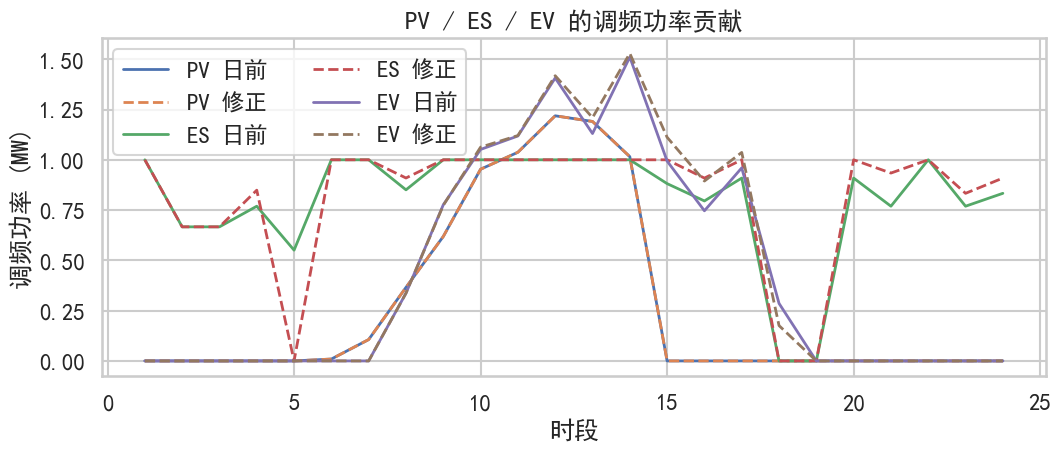

### 市场价格曲线

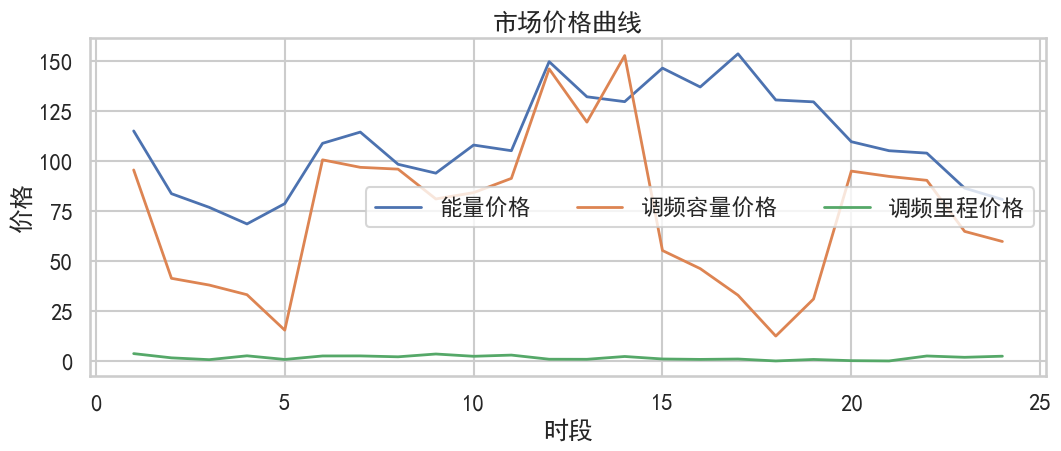

### 利润对比与滚动修正频次

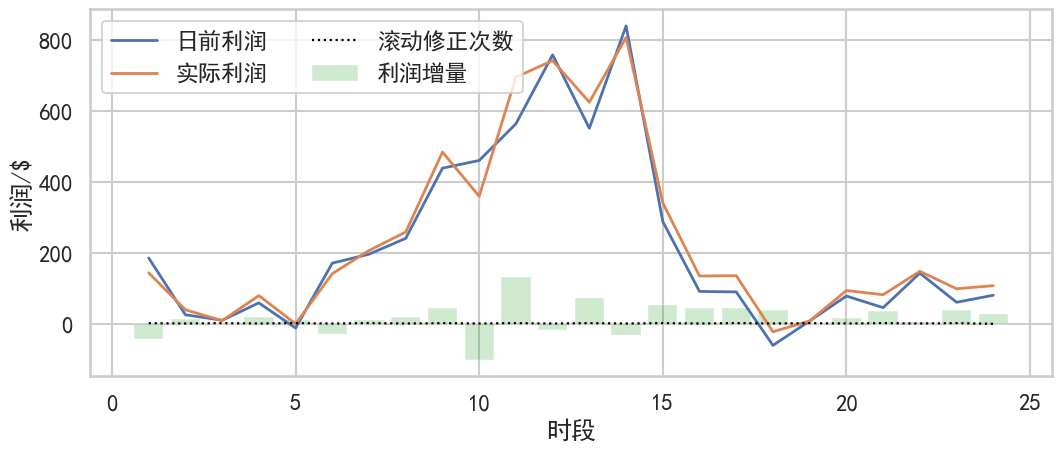

In [ ]:
base_day = resource_df.pivot(index="slot", columns="resource_type", values="bid_p_day")
base_rev = resource_df.pivot(index="slot", columns="resource_type", values="bid_p_rev")
reg_day = resource_df.pivot(index="slot", columns="resource_type", values="bid_r_day")
reg_rev = resource_df.pivot(index="slot", columns="resource_type", values="bid_r_rev")

display(Markdown("### 基础功率资源贡献"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
for resource_name in ["PV", "ES", "EV"]:
    ax.plot(base_day.index, base_day[resource_name], linewidth=2.0, label=f"{resource_name} 日前")
    ax.plot(base_rev.index, base_rev[resource_name], linewidth=2.0, linestyle="--", label=f"{resource_name} 修正")
ax.set_xlabel("时段")
ax.set_ylabel("基础功率 (MW)")
ax.set_title("PV / ES / EV 的基础功率贡献")
ax.legend(ncol=2)
plt.show()

display(Markdown("### 调频功率资源贡献"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
for resource_name in ["PV", "ES", "EV"]:
    ax.plot(reg_day.index, reg_day[resource_name], linewidth=2.0, label=f"{resource_name} 日前")
    ax.plot(reg_rev.index, reg_rev[resource_name], linewidth=2.0, linestyle="--", label=f"{resource_name} 修正")
ax.set_xlabel("时段")
ax.set_ylabel("调频功率 (MW)")
ax.set_title("PV / ES / EV 的调频功率贡献")
ax.legend(ncol=2)
plt.show()

display(Markdown("### 市场价格曲线"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
ax.plot(slot_df["slot"], slot_df["price_e"], linewidth=2.0, label="能量价格")
ax.plot(slot_df["slot"], slot_df["price_reg_cap"], linewidth=2.0, label="调频容量价格")
ax.plot(slot_df["slot"], slot_df["price_reg_mileage"], linewidth=2.0, label="调频里程价格")
ax.set_xlabel("时段")
ax.set_ylabel("价格")
ax.set_title("市场价格曲线")
ax.legend(ncol=3)
plt.show()

display(Markdown("### 利润对比与滚动修正频次"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
ax.plot(slot_df["slot"], slot_df["profit_day"], linewidth=2.0, label="日前利润")
ax.plot(slot_df["slot"], slot_df["profit_actual"], linewidth=2.0, label="实际利润")
ax.bar(slot_df["slot"], slot_df["profit_delta"], alpha=0.22, color="tab:green", label="利润增量")
ax.plot(slot_df["slot"], slot_df["revision_count"], linewidth=1.6, color="black", linestyle=":", label="滚动修正次数")
ax.set_xlabel("时段")
ax.set_ylabel("利润/$")
# ax.set_title("利润对比与滚动修正频次")
ax.legend(ncol=2)
plt.show()


未检测到交互控件，修改下方默认车辆编号后重跑本单元即可切换车辆。


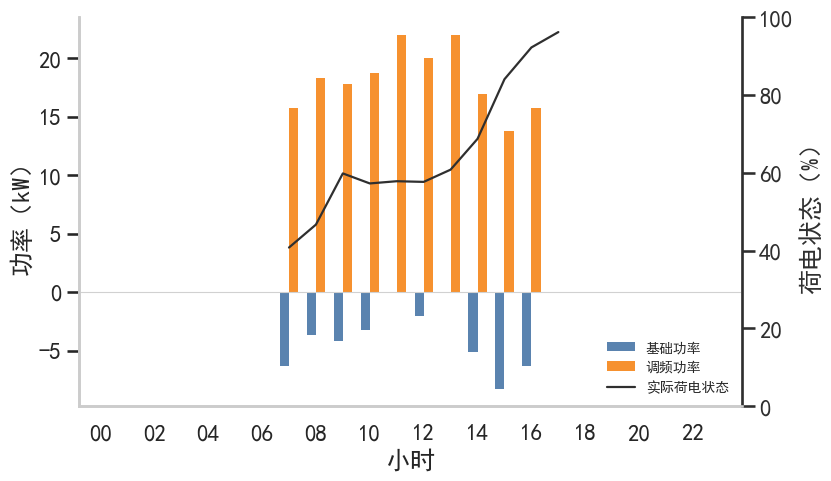

In [ ]:
def plot_selected_ev(ev_number=1):
    slot_ev_df = build_selected_ev_slot_df(sim, int(ev_number))
    actual_ev_df = build_selected_ev_actual_df(sim, int(ev_number))
    ev_label = slot_ev_df["ev_label"].iat[0]
    vehicle_label = str(ev_label).replace("EV_", "车辆")

    x = np.arange(sim["NOFSLOTS"], dtype=float)
    hour_labels = [f"{int(hour):02d}" for hour in slot_ev_df["hour"].to_numpy(dtype=float)]
    available_mask = slot_ev_df["available"].to_numpy(dtype=bool)

    bid_p_rev = slot_ev_df["bid_p_rev"].where(slot_ev_df["available"], np.nan).to_numpy(dtype=float) * 1000.0
    bid_r_rev = slot_ev_df["bid_r_rev"].where(slot_ev_df["available"], np.nan).to_numpy(dtype=float) * 1000.0

    soc_actual_df = actual_ev_df.groupby("slot", as_index=False).agg(
        soc_actual_pct=("soc_end_pct", lambda s: float(s.iloc[-1])),
    )
    soc_df = pd.DataFrame({"slot": np.arange(1, sim["NOFSLOTS"] + 1, dtype=int)})
    soc_df = soc_df.merge(soc_actual_df, on="slot", how="left")
    soc_df.loc[~available_mask, "soc_actual_pct"] = np.nan

    fig, ax1 = plt.subplots(figsize=FIGSIZE_EV, constrained_layout=True)
    ax1.axhline(0.0, color="0.82", linewidth=0.8)
    bar_width = 0.34
    bars_bid_p = ax1.bar(
        x - bar_width / 2,
        bid_p_rev,
        width=bar_width,
        color="#4c78a8",
        alpha=0.92,
        linewidth=0.0,
        label="修正后基础功率",
    )
    bars_bid_r = ax1.bar(
        x + bar_width / 2,
        bid_r_rev,
        width=bar_width,
        color="#f58518",
        alpha=0.90,
        linewidth=0.0,
        label="修正后调频功率",
    )
    ax1.set_xlim(-0.8, sim["NOFSLOTS"] - 0.2)
    ax1.set_xticks(np.arange(0, sim["NOFSLOTS"], 2))
    ax1.set_xticklabels(hour_labels[::2])
    ax1.set_xlabel("小时")
    ax1.set_ylabel("功率（kW）")
    ax1.grid(False)
    ax1.spines["top"].set_visible(False)

    ax2 = ax1.twinx()
    line_soc, = ax2.plot(
        x,
        soc_df["soc_actual_pct"].to_numpy(dtype=float),
        linewidth=1.6,
        color="#2f2f2f",
        label="实际荷电状态",
    )
    ax2.set_ylabel("荷电状态（%）", color="#2f2f2f")
    ax2.tick_params(axis="y", colors="#2f2f2f")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color("#2f2f2f")
    ax2.set_ylim(0.0, 100.0)
    ax2.grid(False)

    handles = [bars_bid_p, bars_bid_r, line_soc]
    labels = ["基础功率", "调频功率", "实际荷电状态"]
    ax1.legend(handles, labels, loc="lower right", frameon=False, fontsize=10)
    plt.show()


ev_count = len(resource_meta["ev_labels"])
if ev_count == 0:
    print("当前结果中没有车辆数据。")
elif widgets is None:
    DEFAULT_VEHICLE = 1
    print("未检测到交互控件，修改下方默认车辆编号后重跑本单元即可切换车辆。")
    plot_selected_ev(DEFAULT_VEHICLE)
else:
    display(Markdown("### 选择单辆车查看详细轨迹"))
    widgets.interact(
        plot_selected_ev,
        ev_number=widgets.IntSlider(value=1, min=1, max=ev_count, step=1, description="车辆编号"),
    )


当前批量查看车辆: [1, 5, 10, 20]


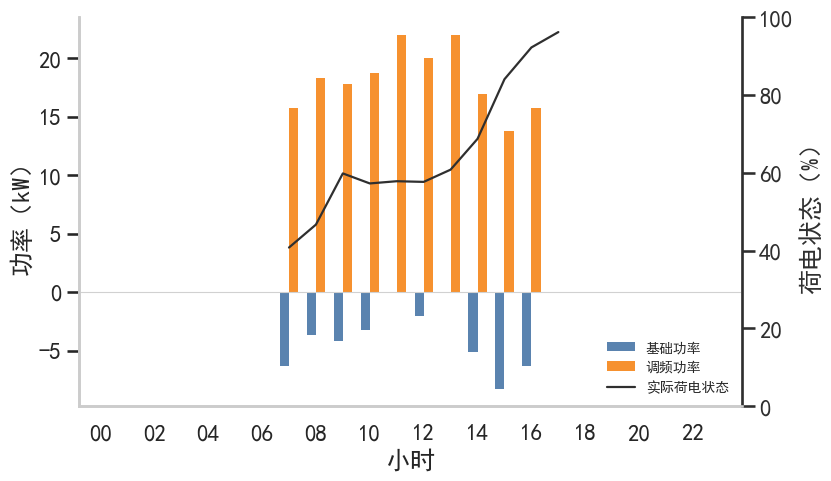

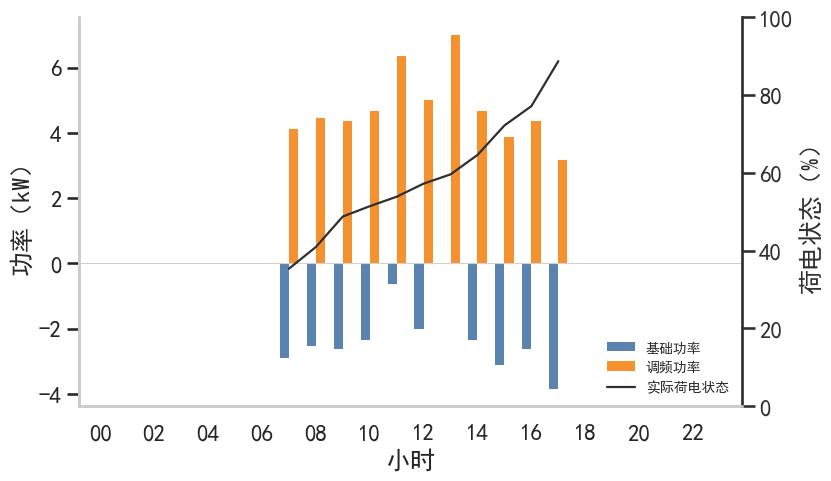

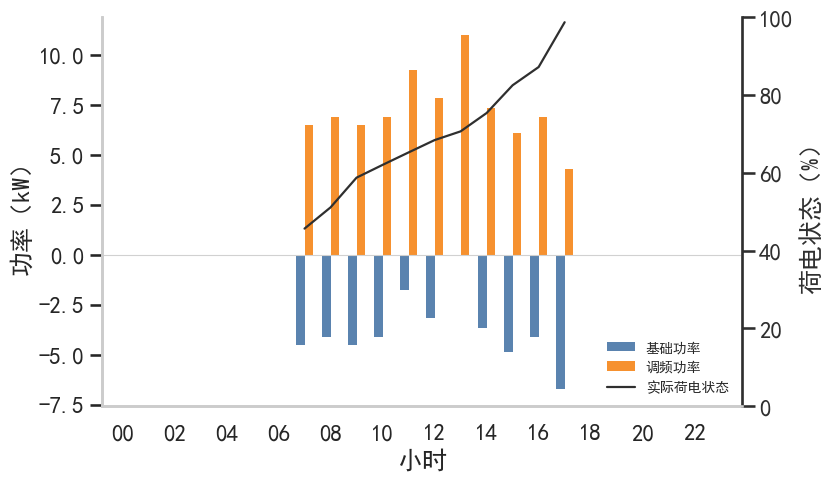

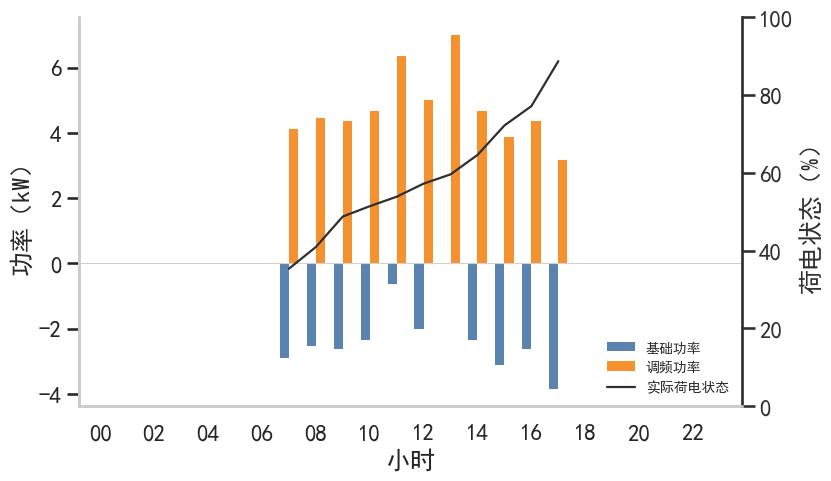

In [ ]:
DEFAULT_MULTI_VEHICLES = [1, 5, 10, 20]
selected_vehicles = []
for ev_number in DEFAULT_MULTI_VEHICLES:
    ev_int = int(ev_number)
    if 1 <= ev_int <= ev_count and ev_int not in selected_vehicles:
        selected_vehicles.append(ev_int)

if ev_count == 0:
    print("当前结果中没有车辆数据。")
elif not selected_vehicles:
    print("默认车辆编号超出范围，请修改 DEFAULT_MULTI_VEHICLES 后重跑本单元。")
else:
    print(f"当前批量查看车辆: {selected_vehicles}")
    for ev_number in selected_vehicles:
        plot_selected_ev(ev_number)


## 使用说明

- 只想改图，不想重跑时，保持 `FORCE_RERUN = False`
- 想拿最新代码重新算一遍时，把 `FORCE_RERUN = True`
- 当前默认使用 `data_process` 的第 `15` 号数据；修改 `DAY_PRICE` 就能切换日期
- 想切换到 `data_prepare` 的 `.mat` 数据，可以把 `DATA_SOURCE` 改成 `"data_prepare"`，并设置 `MAT_FILE`
- 单车图下方新增了批量浏览单元，修改 `DEFAULT_MULTI_VEHICLES` 就能一次看多辆车
- 如果想继续加图，优先复用 `slot_df`、`resource_df`、`heatmaps`、`build_selected_ev_*` 这些对象
